# [WebBaseLoader](https://python.langchain.com/docs/integrations/document_loaders/web_base/)
> 웹페이지(URL)의 텍스트를 가져와 Document로 변환

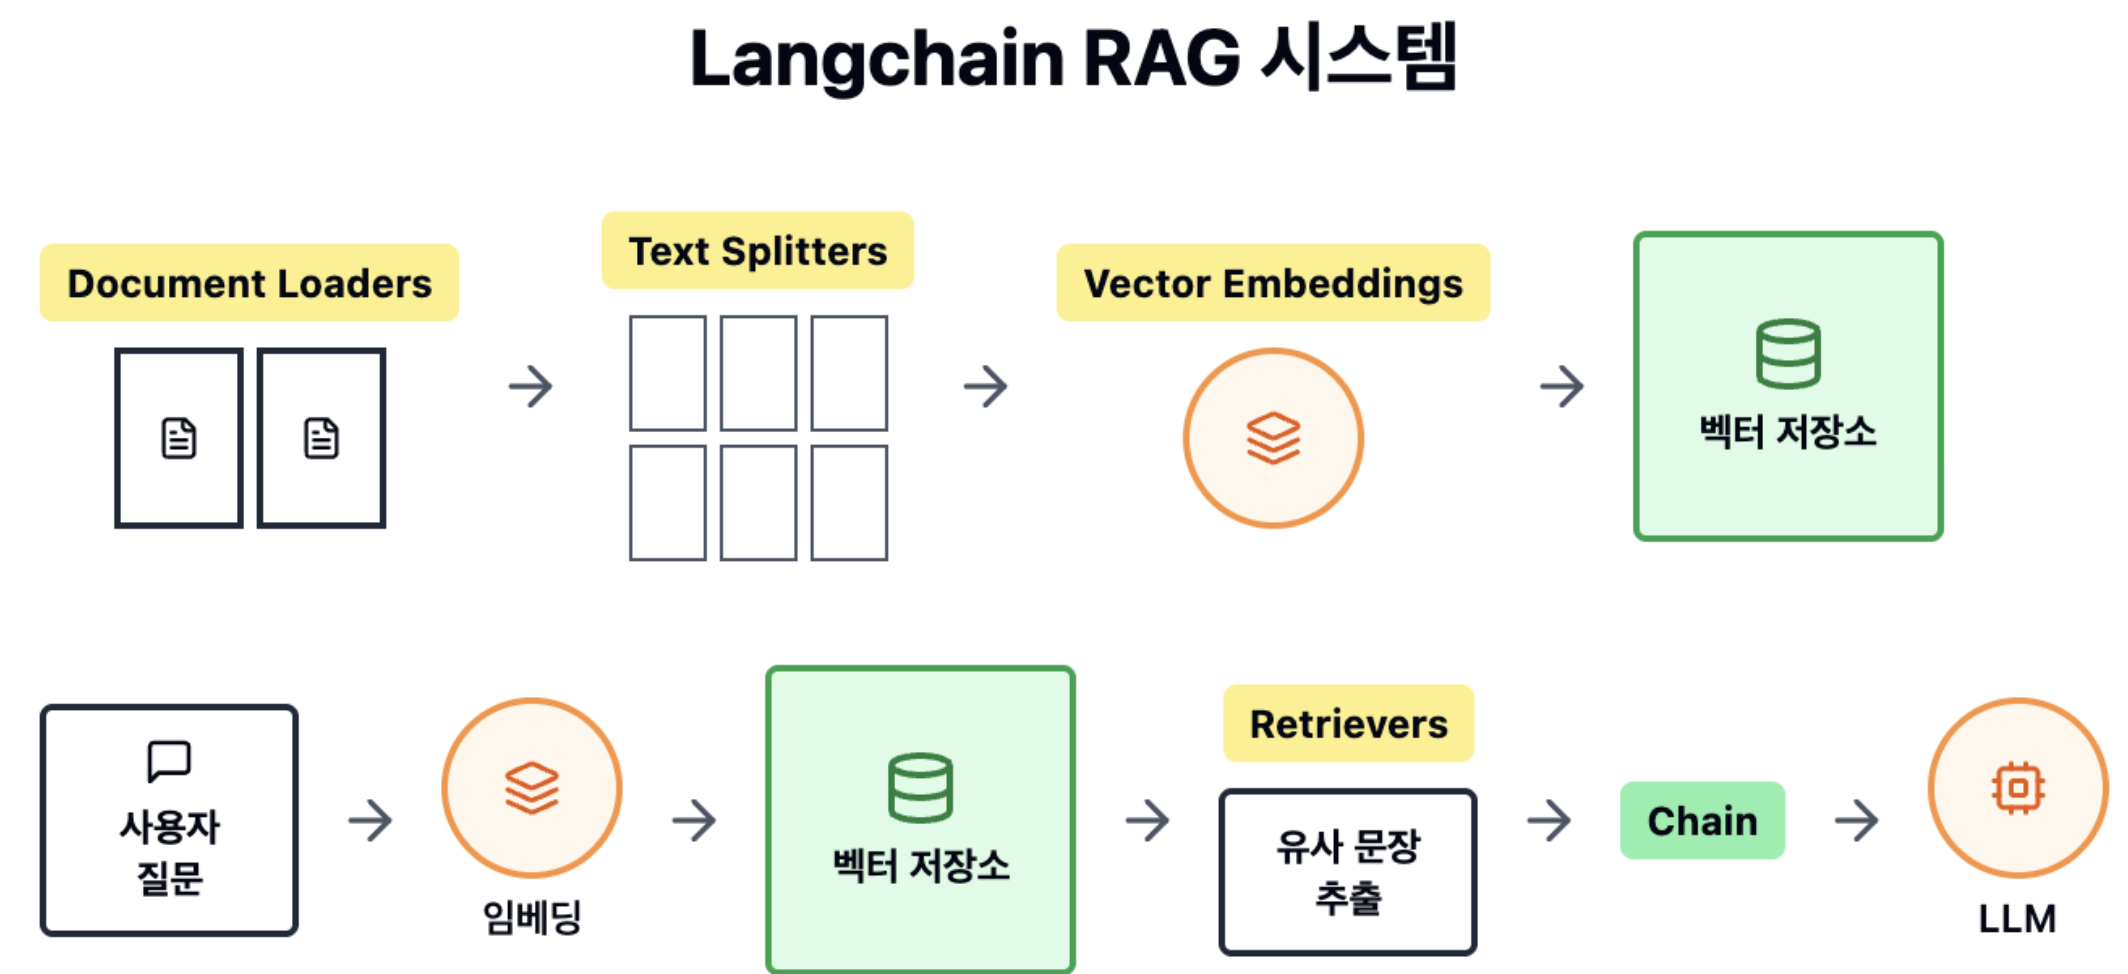

## WebBaseLoader 파라미터 설명

| 파라미터 | 필수 여부 | 설명 | 예시 |
|---------|---------|------|------|
| `web_path` | 필수 | 가져올 웹페이지 주소(URL). 문자열 하나 또는 리스트 | `"https://example.com"` 또는 `["https://example.com", "https://example2.com"]` |
| `header_template` | 선택 | HTTP 요청 헤더 정보. 브라우저 인증이나 User-Agent 설정 | `{"User-Agent": "Mozilla/5.0"}` |
| `verify_ssl` | 선택 | SSL 인증서 검증 여부 (기본값: True) | `False` |
| `requests_kwargs` | 선택 | requests 라이브러리 추가 옵션 (타임아웃, 프록시 등) | `{"timeout": 10}` |
| `bs_kwargs` | 선택 | BeautifulSoup 파싱 옵션 | `{"parse_only": "html.parser"}` |

## Loader

### [example 웹 페이지](https://www.example.com/)

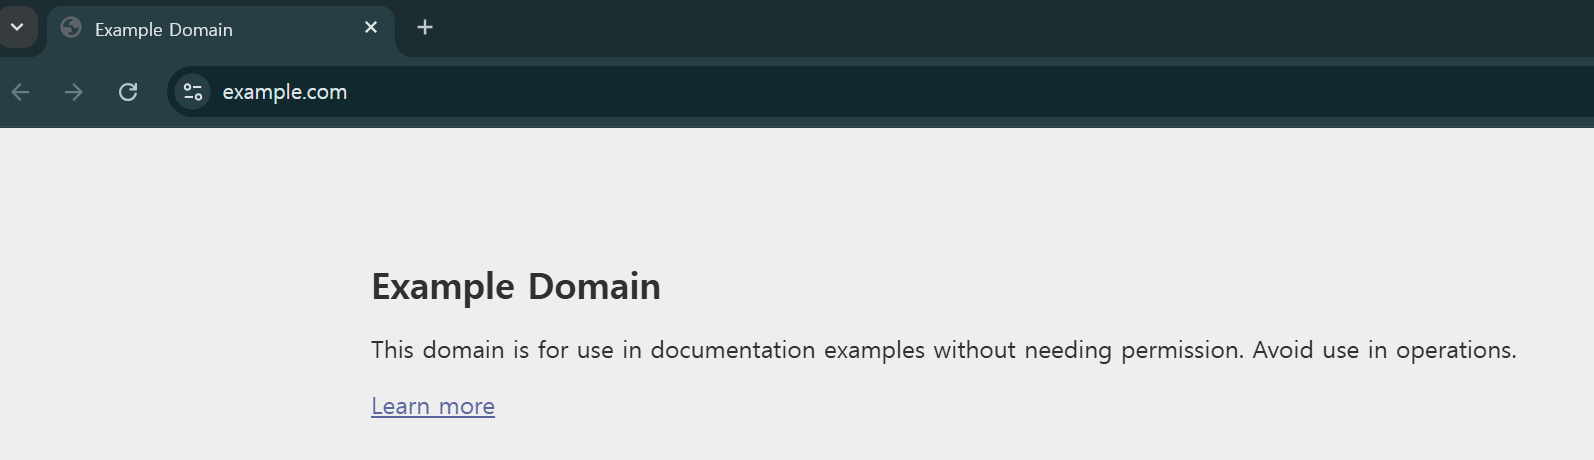

In [8]:
import warnings

# 모든 경고 무시
warnings.filterwarnings("ignore")


In [9]:
from langchain_community.document_loaders import WebBaseLoader

loader = WebBaseLoader(
    web_path="https://www.example.com/", 
    header_template={
        "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36",
    }, 
    verify_ssl=False,
    requests_kwargs={"timeout": 10})

In [10]:
docs = loader.load()

print(f"로드된 문서의 수: {len(docs)}")

로드된 문서의 수: 1


In [11]:
print(f"첫번째 문서의 메타정보 확인:\n {docs[0].metadata}")

첫번째 문서의 메타정보 확인:
 {'source': 'https://www.example.com/', 'title': 'Example Domain', 'language': 'en'}


In [12]:
print(f"첫번째 문서의 데이터 확인:\n {docs[0].page_content}")

첫번째 문서의 데이터 확인:
 Example DomainExample DomainThis domain is for use in documentation examples without needing permission. Avoid use in operations.Learn more



## Multiple Pages

In [13]:
from langchain_community.document_loaders import WebBaseLoader

loader = WebBaseLoader(
    web_paths=["https://www.example.com/", "https://google.com"])

docs = loader.load()
print(f"로드된 문서의 수: {len(docs)}")

로드된 문서의 수: 2


In [14]:
for i, doc in enumerate(docs):
    print("="*50)
    print(f"Document {i+1}:")
    print(f"   - 타입: {type(doc)}")
    print(f"   - page_content 타입: {type(doc.page_content)}")
    print(f"   - metadata 타입: {type(doc.metadata)}")
    print(f"   - metadata 내용: {doc.metadata}")
    print(f"   - 내용 길이: {len(doc.page_content)} 문자")
    print()

Document 1:
   - 타입: <class 'langchain_core.documents.base.Document'>
   - page_content 타입: <class 'str'>
   - metadata 타입: <class 'dict'>
   - metadata 내용: {'source': 'https://www.example.com/', 'title': 'Example Domain', 'language': 'en'}
   - 내용 길이: 140 문자

Document 2:
   - 타입: <class 'langchain_core.documents.base.Document'>
   - page_content 타입: <class 'str'>
   - metadata 타입: <class 'dict'>
   - metadata 내용: {'source': 'https://google.com', 'title': 'Google', 'language': 'ko'}
   - 내용 길이: 144 문자



## Loader with bs4

### [네이트 판 댓글 추출](https://pann.nate.com/talk/350939697)

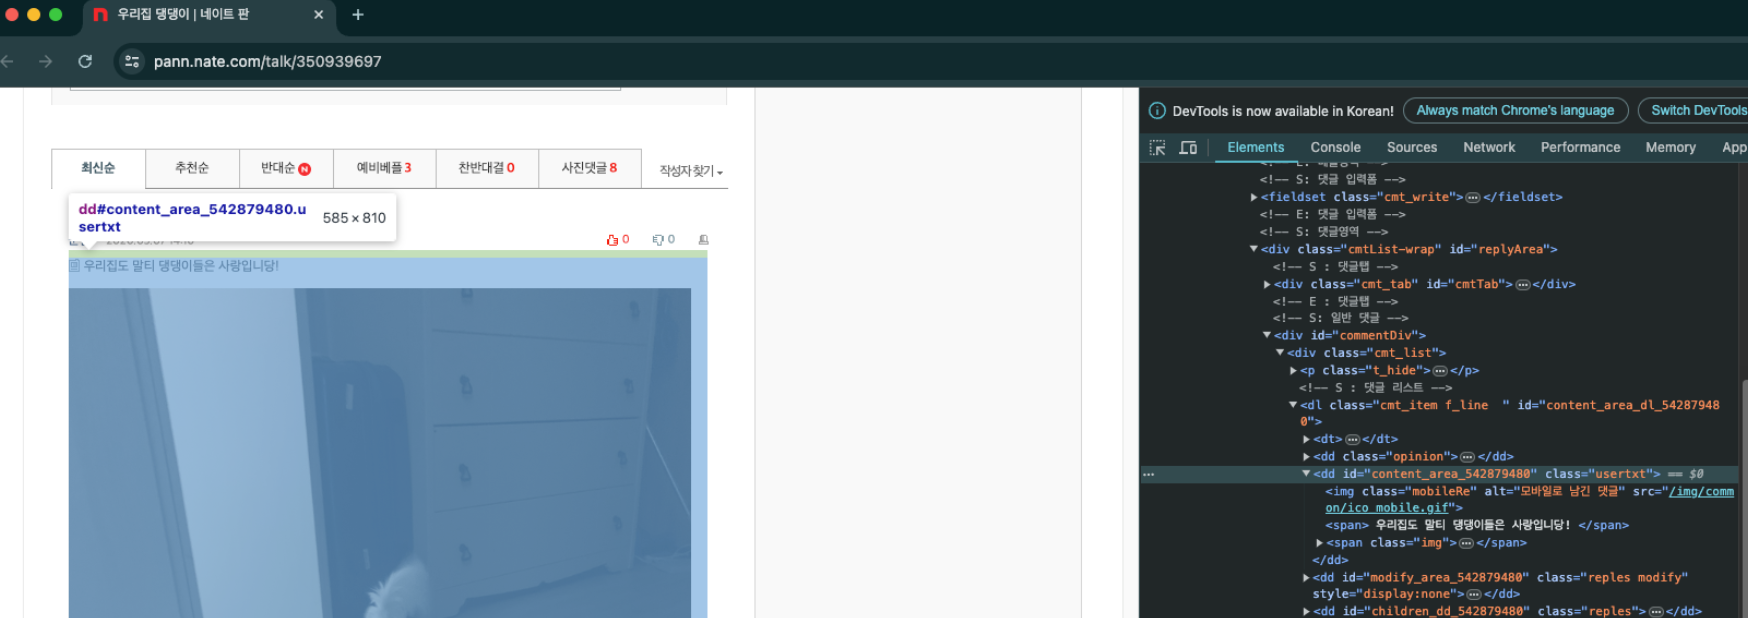

### BS4를 사용한 특정 요소 추출 예제

In [15]:
import requests
from bs4 import BeautifulSoup as bs

def main():
    custom_header = {
        "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36",
        "referer": "https://pann.ante.com/"
    }
    url = "https://pann.nate.com/talk/350939697"
    response = requests.get(url, headers=custom_header)
    response.raise_for_status()
    soup = bs(response.text, "html.parser")

    return soup

In [16]:
soup = main()

In [17]:
def crawling(soup):
    dd_list = soup.find_all("dd", class_="usertxt")

    for idx, dd in enumerate(dd_list):
        comment = dd.get_text().replace("\n","").replace("\t","")
        print(f'{idx}번째 댓글\n>> {comment}')

In [18]:
crawling(soup)

0번째 댓글
>>  우리 댕댕이ㅋ 
1번째 댓글
>> 우리집도 말티 댕댕이들은 사랑입니당! 
2번째 댓글
>> ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ 다이쁨 완전 얼짱이넹
3번째 댓글
>> 우리 딸랑이 
4번째 댓글
>> 말티는 사랑입니당^^ 
5번째 댓글
>> 너무 귀엽당^^
6번째 댓글
>> 밑에서 두번째 사진 털때문인지 뾰루퉁한거 넘 귀여워요 ㅋㅋㅋㅋㅋ!울집강아지도 털때문에 가끔 눈이 화난눈 되거든요 ㅎㅎㅎㅎ 귀엽 ㅠ.ㅠ*
7번째 댓글
>> 우리집도 
8번째 댓글
>> 달릴 때 졸귘ㅋㅋ 눈이랑 코랑 동글동글 너무 귀엽 ㅠㅠㅠㅠㅠ
9번째 댓글
>> 안녕 칭구 
10번째 댓글
>> 개똥냄새 쩔게 생겼네
11번째 댓글
>> 안녕 난 두부야 
12번째 댓글
>> 아 너모 이쁘다. 항상 건강하자 아가
13번째 댓글
>> 힐링하고 갑니다❤️
14번째 댓글
>> 안뇽 ? 
15번째 댓글
>> 네츄럴 부스스.. 예쁘네요..^^
16번째 댓글
>> 으악 싑알 넘귀여워 말티즈 사랑해말티즈최고 말티즈 너무귀엽다
17번째 댓글
>> 순백의 청순함에서 깨발랄 ㅋ귀엽네요
18번째 댓글
>> 우리 댕댕이ㅋ 
19번째 댓글
>> 어머나!


### WebBaseLoader로 네이트 판 댓글 추출


In [19]:
from langchain_community.document_loaders import WebBaseLoader
from bs4 import SoupStrainer

# 네이트 판 댓글 추출용 WebBaseLoader 생성
loader = WebBaseLoader(
    # 가져올 웹페이지 주소 (네이트 판)
    web_path="https://pann.nate.com/talk/350939697",
    
    # HTTP 요청 헤더 설정
    header_template={
        "user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36",
        "referer": "https://pann.nate.com/"
    },
    
    # BeautifulSoup 파싱 옵션
    bs_kwargs={
        # SoupStrainer: dd 태그 중 class가 'usertxt'인 요소만 추출
        "parse_only": SoupStrainer(
            'dd',  # dd 태그만
            attrs={'class': 'usertxt'}  # class가 'usertxt'인 것만
        )
    },
    
    # 텍스트 추출 옵션
    bs_get_text_kwargs={
        # 텍스트 사이에 넣을 구분자 (각 댓글을 줄바꿈으로 구분)
        "separator": "\n",
        # 앞뒤 공백 제거 활성화
        "strip": True
    },
    
    # HTTP 요청 옵션
    requests_kwargs={
        "timeout": 10,
        "verify": False
    }
)

# 문서 로드
docs = loader.load()
print(f"로드된 문서의 수: {len(docs)}")


로드된 문서의 수: 1


In [20]:
# 추출된 댓글 내용 확인
print("추출된 댓글 내용:")
print("=" * 50)
print(docs[0].page_content)


추출된 댓글 내용:
우리 댕댕이ㅋ
우리집도 말티 
댕댕이들은 사랑입니당!
ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ 다이쁨 완전 얼짱이넹
우리 딸랑이
말티는 사랑입니당^^
너무 귀엽당^^
밑에서 두번째 사진 털때문인지 뾰루퉁한거 넘 귀여워요 ㅋㅋㅋㅋㅋ!
울집강아지도 털때문에 가끔 눈이 화난눈 되거든요 ㅎㅎㅎㅎ 귀엽 ㅠ.ㅠ*
우리집도
달릴 때 졸귘ㅋㅋ 눈이랑 코랑 동글동글 너무 귀엽 ㅠㅠㅠㅠㅠ
안녕 칭구
개똥냄새 쩔게 생겼네
안녕 난 두부야
아 너모 이쁘다. 항상 건강하자 아가
힐링하고 갑니다❤️
안뇽 ?
네츄럴 부스스.. 예쁘네요..^^
으악 싑알 넘귀여워 말티즈 사랑해말티즈최고 말티즈 너무귀엽다
순백의 청순함에서 깨발랄 ㅋ
귀엽네요
우리 댕댕이ㅋ
어머나!


In [21]:
# 댓글을 개별적으로 분리하여 출력
comments = docs[0].page_content.split('\n')
print(f"총 {len(comments)}개의 댓글이 추출되었습니다.\n")

for idx, comment in enumerate(comments[:5]):  # 처음 5개만 출력
    print(f"{idx}번째 댓글")
    print(f">> {comment}")
    print()


총 23개의 댓글이 추출되었습니다.

0번째 댓글
>> 우리 댕댕이ㅋ

1번째 댓글
>> 우리집도 말티 

2번째 댓글
>> 댕댕이들은 사랑입니당!

3번째 댓글
>> ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ 다이쁨 완전 얼짱이넹

4번째 댓글
>> 우리 딸랑이

